# TP 3 — Matplotlib & histogrammes : solution commentée

Solution complète du [TP 3](./enonce.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import data

img_gray = np.array(Image.fromarray(data.moon()))
img_rgb = np.array(Image.fromarray(data.coffee()))

## Exercice 1 — Affichage propre et colorbar

Affichez `img_gray` et `img_rgb` côte à côte avec :

- une figure de taille raisonnable (`figsize=(10, 4)`),
- un titre pour chaque sous-graphe,
- les axes désactivés,
- `cmap="gray"` et `vmin=0, vmax=255` pour l'image en niveaux de gris.

**Ajout — colorbar avec une colormap perceptuelle** : créez ensuite **une troisième figure** affichant `img_gray` avec la colormap `"viridis"` et **une colorbar visible à droite** (`plt.colorbar(im, ax=ax)`). C'est l'affichage type quand on visualise une grandeur scalaire (carte de profondeur, heatmap d'activation, intensité d'un capteur).

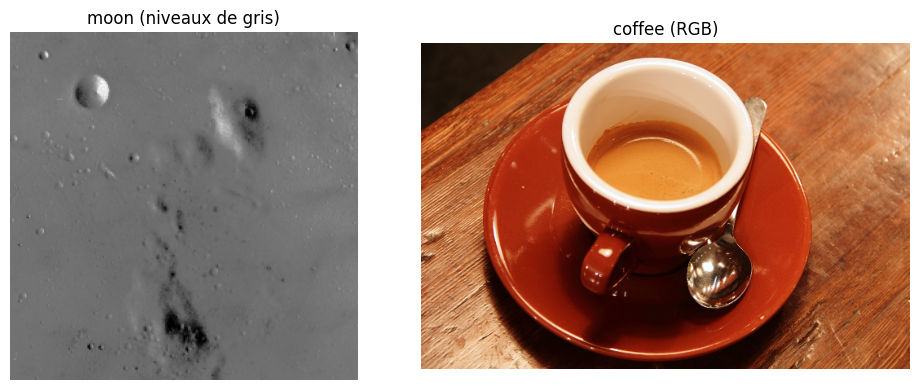

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("moon (niveaux de gris)")
axes[1].imshow(img_rgb)
axes[1].set_title("coffee (RGB)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

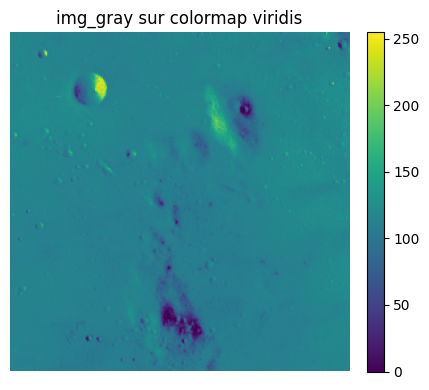

In [3]:
# 2e figure : colormap viridis + colorbar
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(img_gray, cmap="viridis")
ax.set_title("img_gray sur colormap viridis")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

## Exercice 2 — Histogramme en niveaux de gris

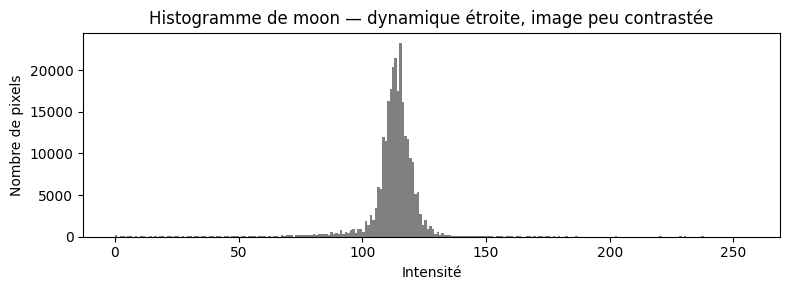

In [4]:
hist, edges = np.histogram(img_gray, bins=256, range=(0, 256))
centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(8, 3))
plt.bar(centers, hist, width=1.0, color="gray")
plt.xlabel("Intensité")
plt.ylabel("Nombre de pixels")
plt.title("Histogramme de moon — dynamique étroite, image peu contrastée")
plt.tight_layout()

## Exercice 3 — Histogramme par canal RGB

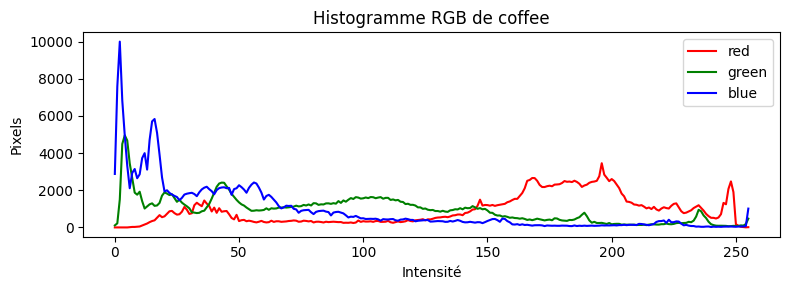

In [5]:
plt.figure(figsize=(8, 3))
for i, color in enumerate(["red", "green", "blue"]):
    h, _ = np.histogram(img_rgb[..., i], bins=256, range=(0, 256))
    plt.plot(h, color=color, label=color)
plt.xlabel("Intensité")
plt.ylabel("Pixels")
plt.title("Histogramme RGB de coffee")
plt.legend()
plt.tight_layout()

## Exercice 4 — Étirement de contraste par percentiles

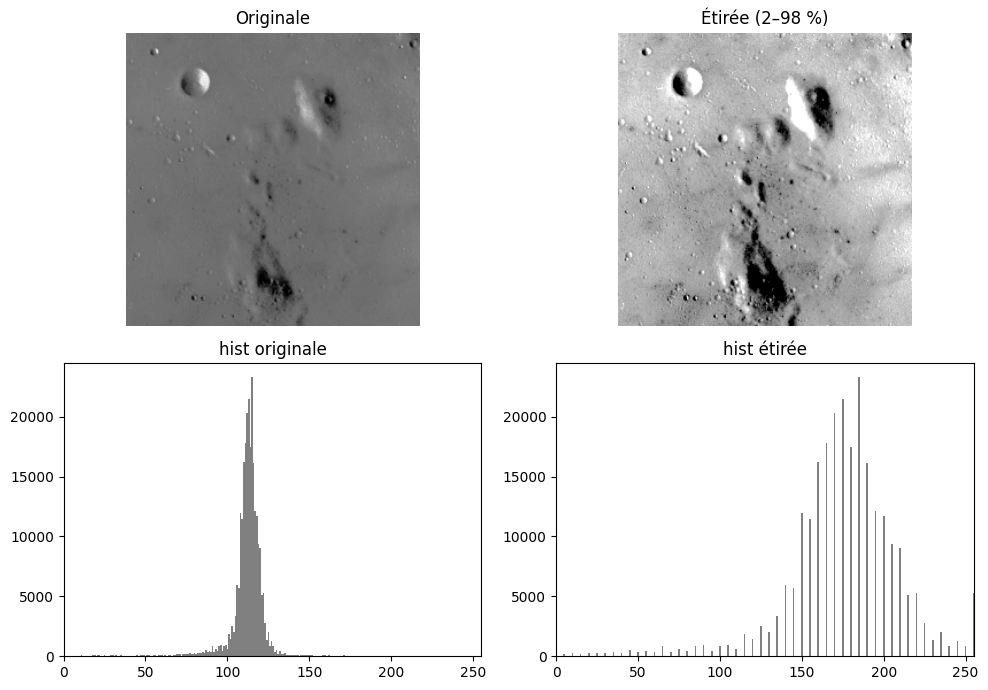

In [6]:
def stretch(img: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    """Étire le contraste sur la plage des percentiles [p_low, p_high]."""
    a, b = np.percentile(img, [p_low, p_high])
    out = (img.astype(np.float32) - a) * 255.0 / max(b - a, 1e-6)
    return np.clip(out, 0, 255).astype(np.uint8)


img_stretched = stretch(img_gray)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Originale")
axes[0, 1].imshow(img_stretched, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title("Étirée (2–98 %)")
for ax in axes[0]:
    ax.axis("off")

for ax, im, title in zip(axes[1], [img_gray, img_stretched], ["hist originale", "hist étirée"]):
    h, _ = np.histogram(im, bins=256, range=(0, 256))
    ax.bar(np.arange(256), h, width=1.0, color="gray")
    ax.set_xlim(0, 255)
    ax.set_title(title)
plt.tight_layout()

## Exercice 5 — Égalisation et correction gamma

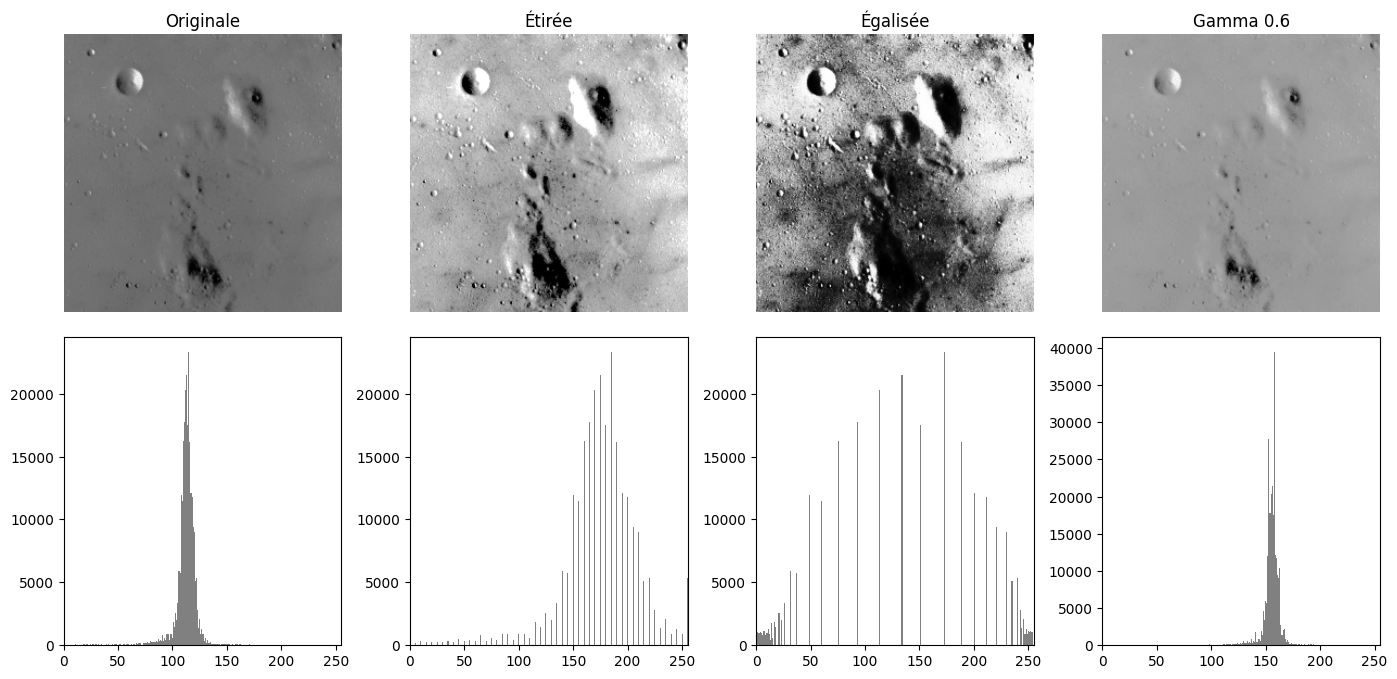

In [7]:
def equalize(img: np.ndarray) -> np.ndarray:
    """Égalisation d'histogramme manuelle pour image uint8."""
    hist, _ = np.histogram(img, bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf = 255 * cdf / cdf[-1]
    return cdf[img].astype(np.uint8)


def gamma(img: np.ndarray, g: float) -> np.ndarray:
    out = 255.0 * (img.astype(np.float32) / 255.0) ** g
    return np.clip(out, 0, 255).astype(np.uint8)


img_eq = equalize(img_gray)
img_gamma = gamma(img_gray, 0.6)

images = [img_gray, img_stretched, img_eq, img_gamma]
titles = ["Originale", "Étirée", "Égalisée", "Gamma 0.6"]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, im, title in zip(axes[0], images, titles):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

for ax, im in zip(axes[1], images):
    h, _ = np.histogram(im, bins=256, range=(0, 256))
    ax.bar(np.arange(256), h, width=1.0, color="gray")
    ax.set_xlim(0, 255)
plt.tight_layout()

**Discussion**

- L'étirement linéaire ouvre la dynamique mais conserve la forme de l'histogramme.
- L'égalisation rend l'histogramme quasi-uniforme : tous les niveaux sont (presque) équiprobables. Le contraste local est très accentué, parfois au prix d'un rendu artificiel.
- La correction gamma compresse non linéairement les valeurs : avec γ < 1 elle éclaircit les zones sombres tout en préservant les hautes lumières.

Le « bon » traitement dépend de l'objectif : maximiser l'information visuelle (égalisation), produire un rendu naturel (gamma), ou simplement utiliser toute la dynamique (étirement).